# Parameter Impact on the BH-BH Merger Rate

For each **parameter family** (e.g. common-envelope efficiency, stellar evolution tracks), this notebook shows — in one panel per family — how the local BH-BH merger rate changes across the model variations reported in the isolated-binary-evolution literature.

**Figure layout:**  
- One panel per parameter family.  
- One row per study that varies that parameter.  
- One scatter point per named sub-model of that study, connected by a thin horizontal line.  
- Fiducial / reference sub-model highlighted with a gold star (★).  
- Where a sub-model internally spans a range (multiple rate rows, e.g. metallicity bins), a shaded error bar shows [min, max].  

**Data source:** `Data_Mandel_and_Broekgaarden_2026/isolated-binary-evolution.csv`

In [1]:
from pathlib import Path
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib import rc, rcParams

warnings.filterwarnings('ignore')

# ── Match the style of plot_rates.py ────────────────────────────────────────
rc("font", family="serif", weight="bold")
rc("text", usetex=True)
rcParams["text.latex.preamble"] = r"\usepackage{amsmath}" + "\n" + r"\boldmath"
rc("axes", linewidth=1.8)
rcParams.update({
    "xtick.major.size": 10, "ytick.major.size": 10,
    "xtick.minor.size": 6,  "ytick.minor.size": 6,
    "font.weight": "bold",
})

FONTSIZE       = 16
IBE_COLOR      = "#e07830"   # warm orange used for isolated-binary-evolution
FIDUCIAL_COLOR = "#f1c40f"   # gold for fiducial / reference sub-model
FIDUCIAL_EDGE  = "#b7950b"

_LATEX_ESCAPES = str.maketrans({"&": r"\&", "%": r"\%", "#": r"\#"})
def _tex(s: str) -> str:
    return s.translate(_LATEX_ESCAPES)

In [2]:
# ── Load data ────────────────────────────────────────────────────────────────
DATA_DIR = Path("../Data_Mandel_and_Broekgaarden_2026")

# The relationships CSV drives this figure — BH-BH rates are embedded per submodel.
rels = pd.read_csv(DATA_DIR / "isolated-binary-evolution_relationships.csv")
rels["from_rate"] = pd.to_numeric(rels["from_rate_Gpc3yr"], errors="coerce")
rels["to_rate"]   = pd.to_numeric(rels["to_rate_Gpc3yr"],   errors="coerce")

# Pull publication year from the main CSV for within-panel sort order
_year_map = (
    pd.read_csv(DATA_DIR / "isolated-binary-evolution.csv", dtype=str).fillna("")
    .drop_duplicates("study_key")
    .set_index("study_key")["year"]
    .apply(pd.to_numeric, errors="coerce")
)
rels["year"] = rels["study_key"].map(_year_map)

print(f"Relationships loaded: {len(rels)} rows, {rels['study_key'].nunique()} studies")
print(f"Unique parameters:    {sorted(rels['parameter'].unique())}")

Relationships loaded: 1052 rows, 27 studies
Unique parameters:    ['$T_{eff}$', 'BH_spin_coupling', 'BPASS_rate_method', 'BPS_code', 'CE optimistic/pessimistic', 'CE_criterion', 'CE_pessimistic', 'DTD_gamma', 'HG_CE_treatment', 'HG_MT_stability', 'IMF', 'MT_stability', 'MT_timescale_switch', 'PISN_mass_threshold', 'PISN_prescription', 'RMP', 'SFRD_model', 'ST_tide', 'Z_OH_0', 'aMZR', 'alpha_CE', 'alpha_CE & lambda_CE', 'alpha_CE_lambda', 'beta_MT', 'bhflag', 'ce_mergeflag', 'ceflag', 'convection_criterion', 'eddlimflag', 'f_WR', 'f_core', 'f_disk', 'fmix', 'gamma_AM', 'initial_binary_distributions', 'kick_prescription', 'kickflag', 'lambda_CE', 'max_stellar_radius', 'metallicity_calibration', 'multi-parameter', 'nabla_FMR_0', 'q_crit', 'sigma_BH', 'sigma_kick', 'stellar_uncertainty', 'supernova_engine', 'zeta_stability']


In [3]:
# ── Map each specific parameter → display panel ──────────────────────────────
# Studies that vary multiple parameters will appear in multiple panels.
PARAMETER_TO_PANEL = {
    # CE efficiency
    "alpha_CE":              r"CE efficiency ($\alpha_{\rm CE}$)",
    "alpha_CE_lambda":       r"CE efficiency ($\alpha_{\rm CE}$)",
    "gamma_CE":              r"CE efficiency ($\alpha_{\rm CE}$)",
    # CE criterion / pessimistic vs optimistic
    "CE_pessimistic":        r"CE criterion \& pessimistic/optimistic",
    "CE_criterion":          r"CE criterion \& pessimistic/optimistic",
    "HG_CE_treatment":       r"CE criterion \& pessimistic/optimistic",
    "CE optimistic/pessimistic": r"CE criterion \& pessimistic/optimistic",
    # MT efficiency
    "beta_MT":               r"MT efficiency ($\beta$)",
    # MT stability
    "caseBB_stability":      r"MT stability",
    "zeta_stability":        r"MT stability",
    "RLOF_criterion":        r"MT stability",
    "HG_MT_stability":       r"MT stability",
    "MT_timescale_switch":   r"MT stability",
    "q_crit":                r"MT stability",
    # Natal kicks
    "sigma_kick":            r"Natal kicks ($\sigma_{\rm kick}$)",
    "sigma_BH":              r"Natal kicks ($\sigma_{\rm kick}$)",
    "kick_prescription":     r"Natal kicks ($\sigma_{\rm kick}$)",
    # Remnant mass / PISN
    "supernova_engine":      r"Remnant mass prescription",
    "RMP":                   r"Remnant mass prescription",
    "max_NS_mass":           r"Remnant mass prescription",
    "PISN":                  r"Remnant mass prescription",
    "PISN_mass_threshold":   r"Remnant mass prescription",
    "fmix":                  r"Remnant mass prescription",
    "f_core":                r"Remnant mass prescription",
    # Stellar tracks
    "max_stellar_radius":    r"Stellar evolution tracks",
    "convection_criterion":  r"Stellar evolution tracks",
    "BPASS_rate_method":     r"Stellar evolution tracks",
    "stellar_uncertainty":   r"Stellar evolution tracks",
    # SFH
    "SFRD_model":            r"Star formation history",
    "SFR_model":             r"Star formation history",
    "Z_OH_0":                r"Star formation history",
    "aMZR":                  r"Star formation history",
    "nabla_FMR_0":           r"Star formation history",
    "metallicity_calibration": r"Star formation history",
    # Initial conditions
    "initial_binary_distributions": r"Initial conditions",
    "IMF":                   r"Initial conditions",
    # Angular momentum / winds
    "BH_spin_coupling":      r"Angular momentum \& winds",
    "f_WR":                  r"Angular momentum \& winds",
    "gamma_AM":              r"Angular momentum \& winds",
    "f_disk":                r"Angular momentum \& winds",
    # Multi-parameter
    "multi-parameter":       r"Multi-parameter",
}

rels["panel"] = rels["parameter"].map(PARAMETER_TO_PANEL).fillna("Other")

# Build a flat table: one row per unique (panel, study_key, submodel) point.
# Each relationship row contributes its two endpoints; duplicates are removed.
_from = rels[["study_key", "label", "year", "panel",
              "from_submodel", "from_rate"]].rename(
    columns={"from_submodel": "submodel", "from_rate": "rate"})
_to   = rels[["study_key", "label", "year", "panel",
              "to_submodel", "to_rate"]].rename(
    columns={"to_submodel": "submodel", "to_rate": "rate"})

pts = (pd.concat([_from, _to], ignore_index=True)
         .drop_duplicates(subset=["panel", "study_key", "submodel"])
         .copy())
pts["is_fiducial"] = (pts["submodel"].str.lower().str.contains("fiducial") |
                      (pts["submodel"] == "ref"))

# Build a flat table of edges: one row per relationship, carrying its panel.
# Each edge is drawn as its own line segment between its two submodels'
# rates, so a study with several disjoint "chains" (e.g. Boesky's alpha_CE
# sweep repeated at 3 fixed beta_MT values) shows 3 separate segments
# rather than one misleading min-to-max bar across all of them.
edges = (rels[["study_key", "panel", "from_submodel", "to_submodel",
               "from_rate", "to_rate"]]
           .dropna(subset=["from_rate", "to_rate"])
           .copy())

print(f"Total (panel, study, submodel) points: {len(pts)}")
print(f"Edges with both rates available:       {len(edges)}")
print(f"Panels: {sorted(pts['panel'].unique())}")
pts.head(8)

Total (panel, study, submodel) points: 1247
Edges with both rates available:       1047
Panels: ['Angular momentum \\& winds', 'CE criterion \\& pessimistic/optimistic', 'CE efficiency ($\\alpha_{\\rm CE}$)', 'Initial conditions', 'MT efficiency ($\\beta$)', 'MT stability', 'Multi-parameter', 'Natal kicks ($\\sigma_{\\rm kick}$)', 'Other', 'Remnant mass prescription', 'Star formation history', 'Stellar evolution tracks']


,study_key,label,year,panel,submodel,rate,is_fiducial
0,Sgalletta_2025_SEVN,Sgalletta et al. (2025),2025,CE efficiency ($\alpha_{\rm CE}$),Sgalletta_alpha_0_5,255.6,False
1,Sgalletta_2025_SEVN,Sgalletta et al. (2025),2025,CE efficiency ($\alpha_{\rm CE}$),Sgalletta_alpha_1,296.4,False
2,Sgalletta_2025_SEVN,Sgalletta et al. (2025),2025,CE efficiency ($\alpha_{\rm CE}$),Sgalletta_alpha_3,203.3,False
3,Mapelli_2017_MOBSE,Mapelli et al. (2017),2017,CE efficiency ($\alpha_{\rm CE}$),D0.02,145.0,False
4,Mapelli_2017_MOBSE,Mapelli et al. (2017),2017,CE efficiency ($\alpha_{\rm CE}$),D (fiducial),NaN,True
5,Mapelli_2017_MOBSE,Mapelli et al. (2017),2017,Remnant mass prescription,D (fiducial),NaN,True
6,Mapelli_2017_MOBSE,Mapelli et al. (2017),2017,CE criterion \& pessimistic/optimistic,D (fiducial),NaN,True
7,Mapelli_2017_MOBSE,Mapelli et al. (2017),2017,Natal kicks ($\sigma_{\rm kick}$),D (fiducial),NaN,True


In [4]:
# ── Build panel structure ────────────────────────────────────────────────────
PANEL_ORDER = [
    r"CE efficiency ($\alpha_{\rm CE}$)",
    r"CE criterion \& pessimistic/optimistic",
    r"MT efficiency ($\beta$)",
    r"MT stability",
    r"Natal kicks ($\sigma_{\rm kick}$)",
    r"Remnant mass prescription",
    r"Stellar evolution tracks",
    r"Star formation history",
    r"Initial conditions",
    r"Angular momentum \& winds",
    r"Multi-parameter",
]

panels = {}
for panel_name in PANEL_ORDER:
    panel_pts = pts[pts["panel"] == panel_name]
    if panel_pts.empty:
        continue
    panel_edges = edges[edges["panel"] == panel_name]
    studies = (panel_pts.drop_duplicates("study_key")
                        .sort_values("year")["study_key"].tolist())
    panels[panel_name] = {"studies": studies, "pts": panel_pts, "edges": panel_edges}

print("Panels and studies:")
for g, p in panels.items():
    print(f"  [{g}]:")
    for sk in p["studies"]:
        n_sub = p["pts"][p["pts"]["study_key"] == sk]["submodel"].nunique()
        n_edg = (p["edges"]["study_key"] == sk).sum()
        print(f"    {sk}  ({n_sub} submodels, {n_edg} edges)")

Panels and studies:
  [CE efficiency ($\alpha_{\rm CE}$)]:
    Mapelli_2017_MOBSE  (3 submodels, 0 edges)
    Srinivasan_2023_COSMIC  (54 submodels, 48 edges)
    Boesky_2024_COMPAS  (12 submodels, 9 edges)
    Deng_2024_BSE  (324 submodels, 270 edges)
    Zhu_2024_COMPAS  (8 submodels, 6 edges)
    Sgalletta_2025_SEVN  (4 submodels, 3 edges)
    Chattaraj_2025_POSYDON  (2 submodels, 1 edges)
    Li_2025_MOBSE  (3 submodels, 2 edges)
    Boco_2026_SEVN  (54 submodels, 36 edges)
    ArcaSedda_2026_BPop  (2 submodels, 1 edges)
  [CE criterion \& pessimistic/optimistic]:
    Mapelli_2017_MOBSE  (2 submodels, 0 edges)
    Neijssel_2019_COMPAS  (38 submodels, 19 edges)
    Olejak_2021_Startrack  (2 submodels, 1 edges)
    Olejak_2022_Startrack  (12 submodels, 6 edges)
    Chattaraj_2025_POSYDON  (3 submodels, 2 edges)
  [MT efficiency ($\beta$)]:
    Dorozsmai_2022_SeBa  (16 submodels, 8 edges)
    vanSon_2022_SMT_COMPAS  (5 submodels, 4 edges)
    Srinivasan_2023_COSMIC  (18 submodels, 12 

,panel,rmin,rmax,factor,dex,n_models,n_studies,n_below_20,n_20_50,n_above_50,order
0,Multi-parameter,96.291,1138.410,11.822600,1.072713,4,1,0,0,4,10
1,Angular momentum \& winds,0.100,579.000,5790.000000,3.762679,28,5,5,12,11,9
2,Initial conditions,22.000,203.000,9.227273,0.965073,9,2,0,4,5,8
3,Star formation history,16.900,1157.220,68.474556,1.835529,302,5,1,16,285,7
4,Stellar evolution tracks,3.000,162.181,54.060333,1.732879,14,3,3,2,9,6
5,Remnant mass prescription,0.599,438.000,731.218698,2.864047,59,7,16,5,38,5
6,Natal kicks ($\sigma_{\rm kick}$),0.599,1072.000,1789.649416,3.252768,45,7,5,7,33,4
7,MT stability,0.900,695.000,772.222222,2.887742,27,5,5,10,12,3
8,MT efficiency ($\beta$),10.100,417.000,41.287129,1.615815,51,4,3,10,38,2
9,CE criterion \& pessimistic/optimistic,1.190,1157.220,972.453782,2.987869,56,5,3,3,50,1


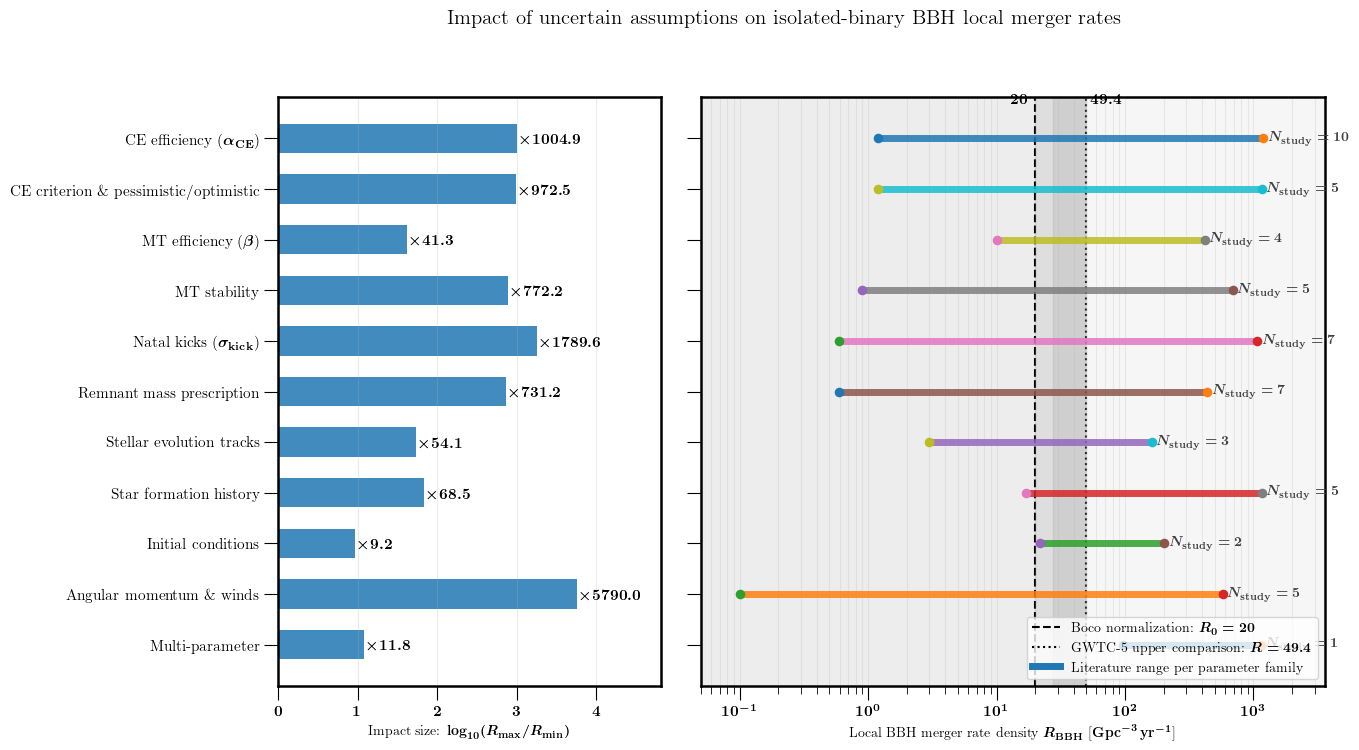

In [5]:
# ── Summary figure: parameter impact + absolute rate range ──────────────────

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# Observational comparison values
BOCO_R0 = 20.0
GWTC5_LOW = 27.5
GWTC5_HIGH = 49.4

# Build one summary row per parameter family.
# This uses all rates in each panel/family.
summary_rows = []
for panel_name in PANEL_ORDER:
    sub = pts[(pts["panel"] == panel_name) & np.isfinite(pts["rate"]) & (pts["rate"] > 0)].copy()
    if sub.empty:
        continue

    rmin = sub["rate"].min()
    rmax = sub["rate"].max()
    factor = rmax / rmin
    dex = np.log10(factor)

    n_models = sub.drop_duplicates(["study_key", "submodel"]).shape[0]
    n_studies = sub["study_key"].nunique()

    n_below_20 = (sub["rate"] < BOCO_R0).sum()
    n_20_50 = ((sub["rate"] >= BOCO_R0) & (sub["rate"] <= GWTC5_HIGH)).sum()
    n_above_50 = (sub["rate"] > GWTC5_HIGH).sum()

    summary_rows.append(dict(
        panel=panel_name,
        rmin=rmin,
        rmax=rmax,
        factor=factor,
        dex=dex,
        n_models=n_models,
        n_studies=n_studies,
        n_below_20=n_below_20,
        n_20_50=n_20_50,
        n_above_50=n_above_50,
    ))

summary = pd.DataFrame(summary_rows)

# Optional: sort by impact size instead of fixed PANEL_ORDER
# summary = summary.sort_values("dex", ascending=True).reset_index(drop=True)

# Keep your preferred order, but plot largest impact at top if sorted is not used
summary["order"] = summary["panel"].map({p: i for i, p in enumerate(PANEL_ORDER)})
summary = summary.sort_values("order", ascending=False).reset_index(drop=True)

display(summary)

# ── Plot settings ────────────────────────────────────────────────────────────

fig_h = 0.55 * len(summary) + 1.6
fig, (ax0, ax1) = plt.subplots(
    ncols=2,
    figsize=(13.5, fig_h),
    gridspec_kw={"width_ratios": [0.95, 1.55], "wspace": 0.08},
    sharey=True,
)

y = np.arange(len(summary))

# Clean labels for y-axis
labels = summary["panel"].values

# ── Left panel: impact size as factor range ──────────────────────────────────

ax0.barh(y, summary["dex"], height=0.58, alpha=0.85)

for yi, row in summary.iterrows():
    ax0.text(
        row["dex"] + 0.04,
        yi,
        rf"$\times {row['factor']:.1f}$",
        va="center",
        ha="left",
        fontsize=11,
    )

ax0.set_xlabel(r"Impact size: $\log_{10}(R_{\max}/R_{\min})$")
ax0.set_yticks(y)
ax0.set_yticklabels(labels, fontsize=12)
ax0.grid(axis="x", alpha=0.25)
ax0.set_xlim(0, max(summary["dex"]) * 1.28)

# ── Right panel: absolute rate range ─────────────────────────────────────────

ax1.set_xscale("log")

# Background comparison regions
ax1.axvspan(1e-3, BOCO_R0, color="0.92", alpha=0.9, zorder=0)
ax1.axvspan(BOCO_R0, GWTC5_HIGH, color="0.82", alpha=0.7, zorder=0)
ax1.axvspan(GWTC5_HIGH, 1e5, color="0.96", alpha=0.9, zorder=0)

# Vertical reference lines
ax1.axvline(BOCO_R0, color="k", lw=1.5, ls="--", zorder=1)
ax1.axvline(GWTC5_HIGH, color="k", lw=1.5, ls=":", zorder=1)
ax1.axvspan(GWTC5_LOW, GWTC5_HIGH, color="0.55", alpha=0.18, zorder=1)

# Rate ranges
for yi, row in summary.iterrows():
    ax1.plot(
        [row["rmin"], row["rmax"]],
        [yi, yi],
        lw=5,
        solid_capstyle="round",
        alpha=0.85,
        zorder=3,
    )
    ax1.scatter(row["rmin"], yi, s=35, zorder=4)
    ax1.scatter(row["rmax"], yi, s=35, zorder=4)

    # Optional: annotate number of studies/models
    ax1.text(
        row["rmax"] * 1.08,
        yi,
        rf"$N_{{\rm study}}={int(row['n_studies'])}$",
        va="center",
        ha="left",
        fontsize=10,
        color="0.25",
    )

ax1.set_xlabel(r"Local BBH merger rate density $R_{\rm BBH}$ [$\mathrm{Gpc}^{-3}\,\mathrm{yr}^{-1}$]")
ax1.grid(axis="x", which="both", alpha=0.22)

xmin = max(1e-2, summary["rmin"].min() / 2)
xmax = summary["rmax"].max() * 3
ax1.set_xlim(xmin, xmax)

# Top labels for comparison regions
top_y = len(summary) - 0.35
ax1.text(BOCO_R0 / 1.15, top_y, r"$20$", ha="right", va="bottom", fontsize=11)
ax1.text(GWTC5_HIGH * 1.08, top_y, r"$49.4$", ha="left", va="bottom", fontsize=11)

legend_elements = [
    Line2D([0], [0], color="k", lw=1.5, ls="--", label=r"Boco normalization: $R_0=20$"),
    Line2D([0], [0], color="k", lw=1.5, ls=":", label=r"GWTC-5 upper comparison: $R=49.4$"),
    Line2D([0], [0], lw=5, label=r"Literature range per parameter family"),
]
ax1.legend(handles=legend_elements, loc="lower right", fontsize=10, frameon=True)

# Final layout
for ax in (ax0, ax1):
    ax.tick_params(axis="both", labelsize=11)

fig.suptitle(
    "Impact of uncertain assumptions on isolated-binary BBH local merger rates",
    fontsize=15,
    y=0.995,
)

plt.savefig("parameter_impact_BHBH_summary_two_panel.pdf", bbox_inches="tight", dpi=250)
plt.savefig("parameter_impact_BHBH_summary_two_panel.png", bbox_inches="tight", dpi=250)
plt.show()

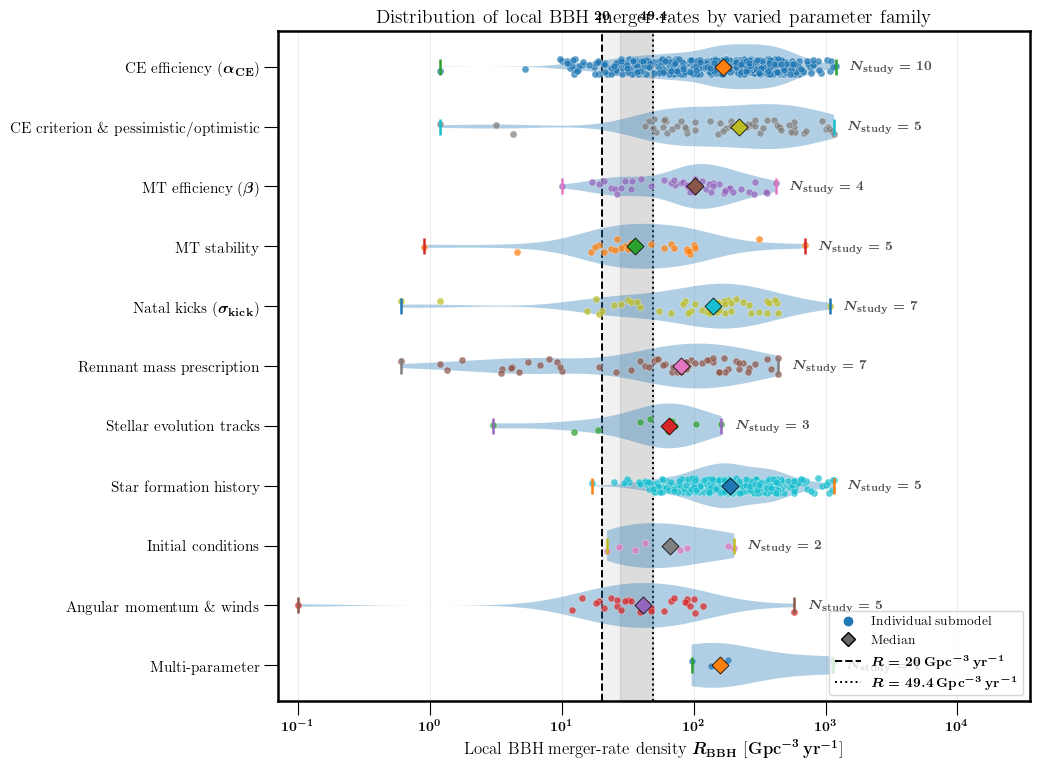

In [6]:
# ── One-panel violin plot: BBH rates by parameter family ────────────────────

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

BOCO_R0 = 20.0
GWTC5_LOW = 27.5
GWTC5_HIGH = 49.4

# Build plotting dataframe from pts
plot_df = pts[np.isfinite(pts["rate"]) & (pts["rate"] > 0)].copy()

# Remove duplicates within each parameter family
plot_df = plot_df.drop_duplicates(
    subset=["panel", "study_key", "submodel", "rate"]
)

# Keep only panels in PANEL_ORDER
plot_df = plot_df[plot_df["panel"].isin(PANEL_ORDER)].copy()

# Use your preferred order
panel_order = [p for p in PANEL_ORDER if p in plot_df["panel"].unique()]
panel_order = panel_order[::-1]  # reverse so first PANEL_ORDER item appears at bottom/top as desired

# Optional: sort by median rate instead
# panel_order = (
#     plot_df.groupby("panel")["rate"]
#     .median()
#     .sort_values()
#     .index
#     .tolist()
# )

# Convert rates to log10 for violin KDE
violin_data = [
    np.log10(plot_df.loc[plot_df["panel"] == panel, "rate"].values)
    for panel in panel_order
]

fig_h = max(5.0, 0.58 * len(panel_order) + 1.4)
fig, ax = plt.subplots(figsize=(10.5, fig_h))

positions = np.arange(len(panel_order))

# Violin plot
parts = ax.violinplot(
    violin_data,
    positions=positions,
    vert=False,
    widths=0.75,
    showmeans=False,
    showmedians=False,
    showextrema=False,
)

for body in parts["bodies"]:
    body.set_alpha(0.35)
    body.set_zorder(2)

# Overlay individual submodels
rng = np.random.default_rng(42)

for i, panel in enumerate(panel_order):
    sub = plot_df.loc[plot_df["panel"] == panel].copy()
    x = np.log10(sub["rate"].values)

    jitter = rng.uniform(-0.13, 0.13, len(sub))

    ax.scatter(
        x,
        i + jitter,
        s=26,
        alpha=0.72,
        edgecolor="white",
        linewidth=0.3,
        zorder=3,
    )

    # Median marker
    ax.scatter(
        np.median(x),
        i,
        marker="D",
        s=75,
        edgecolor="black",
        linewidth=0.55,
        zorder=4,
    )

    # Optional: min/max ticks
    ax.scatter(
        [np.min(x), np.max(x)],
        [i, i],
        marker="|",
        s=120,
        linewidth=1.8,
        zorder=4,
    )

    # Count annotation
    n_models = sub.drop_duplicates(["study_key", "submodel"]).shape[0]
    n_studies = sub["study_key"].nunique()

    ax.text(
        np.max(x) + 0.10,
        i,
        rf"$N_{{\rm study}}={n_studies}$",
        va="center",
        ha="left",
        fontsize=9.5,
        color="0.30",
    )

# Observational comparison regions
ax.axvspan(
    np.log10(BOCO_R0),
    np.log10(GWTC5_HIGH),
    color="0.70",
    alpha=0.18,
    zorder=0,
)

ax.axvspan(
    np.log10(GWTC5_LOW),
    np.log10(GWTC5_HIGH),
    color="0.45",
    alpha=0.16,
    zorder=0,
)

ax.axvline(np.log10(BOCO_R0), color="k", lw=1.4, ls="--", zorder=1)
ax.axvline(np.log10(GWTC5_HIGH), color="k", lw=1.4, ls=":", zorder=1)

# Axes
ax.set_yticks(positions)
ax.set_yticklabels(panel_order, fontsize=11)

xmin = np.floor(np.log10(plot_df["rate"].min()))
xmax = np.ceil(np.log10(plot_df["rate"].max()))

xticks = np.arange(xmin, xmax + 1)
ax.set_xticks(xticks)
ax.set_xticklabels([rf"$10^{{{int(t)}}}$" for t in xticks])

ax.set_xlim(xmin - 0.15, xmax + 0.55)
ax.set_ylim(-0.6, len(panel_order) - 0.4)

ax.set_xlabel(
    r"Local BBH merger-rate density $R_{\rm BBH}$ "
    r"[$\mathrm{Gpc}^{-3}\,\mathrm{yr}^{-1}$]",
    fontsize=12,
)

ax.set_title(
    "Distribution of local BBH merger rates by varied parameter family",
    fontsize=14,
)

ax.grid(axis="x", alpha=0.24)

# Top labels
top_y = len(panel_order) - 0.25

ax.text(
    np.log10(BOCO_R0),
    top_y,
    r"$20$",
    ha="center",
    va="bottom",
    fontsize=10,
)

ax.text(
    np.log10(GWTC5_HIGH),
    top_y,
    r"$49.4$",
    ha="center",
    va="bottom",
    fontsize=10,
)

legend_elements = [
    Line2D([0], [0], marker="o", linestyle="None", markersize=6,
           label="Individual submodel"),
    Line2D([0], [0], marker="D", color="w", markeredgecolor="k",
           markerfacecolor="0.4", linestyle="None", markersize=7,
           label="Median"),
    Line2D([0], [0], color="k", lw=1.4, ls="--",
           label=r"$R=20\,\mathrm{Gpc}^{-3}\,\mathrm{yr}^{-1}$"),
    Line2D([0], [0], color="k", lw=1.4, ls=":",
           label=r"$R=49.4\,\mathrm{Gpc}^{-3}\,\mathrm{yr}^{-1}$"),
]

ax.legend(
    handles=legend_elements,
    loc="lower right",
    fontsize=9.5,
    frameon=True,
)

plt.tight_layout()

plt.savefig(
    "parameter_impact_BHBH_violin_by_family.pdf",
    bbox_inches="tight",
    dpi=300,
)

plt.savefig(
    "parameter_impact_BHBH_violin_by_family.png",
    bbox_inches="tight",
    dpi=300,
)

plt.show()

BBH rate rows: 1509
Unique studies: 56
Unique codes: 14
['B-POP', 'BPASS', 'BSE', 'Brussels code', 'COMBINE', 'COMPAS', 'COSMIC', 'MOBSE', 'POSYDON', 'SEVN', 'Scenario Machine', 'SeBa', 'StarTrack', 'binary c']


,compact_object_type,study_key,label,year,code,submodel,rate
0,BH-BH,OShaughnessy_2010_StarTrack,O'Shaughnessy et al. (2010),2010,StarTrack,,2.0000
1,BH-BH,OShaughnessy_2010_StarTrack,O'Shaughnessy et al. (2010),2010,StarTrack,rate in abstract,4.0000
2,BH-BH,OShaughnessy_2010_StarTrack,O'Shaughnessy et al. (2010),2010,StarTrack,,40.0000
3,BH-BH,Mennekens_2014_Brusselscode,Mennekens and Vanbeveren (2014),2014,Brussels code,16,1138.4100
4,BH-BH,Mennekens_2014_Brusselscode,Mennekens and Vanbeveren (2014),2014,Brussels code,12,182.5200
5,BH-BH,Mennekens_2014_Brusselscode,Mennekens and Vanbeveren (2014),2014,Brussels code,17,135.7200
6,BH-BH,Mennekens_2014_Brusselscode,Mennekens and Vanbeveren (2014),2014,Brussels code,18,96.2910
7,BH-BH,Mennekens_2014_Brusselscode,Mennekens and Vanbeveren (2014),2014,Brussels code,,161.4600
8,BH-BH,Mennekens_2014_Brusselscode,Mennekens and Vanbeveren (2014),2014,Brussels code,,896.2200
9,BH-BH,deMink_2015_StarTrack,de Mink and Belczynski (2015),2015,StarTrack,,540.2000


,code,r_min,r_median,r_max,n_models,n_studies,n_below_20,n_below_49p4,factor_range,dex_range
0,B-POP,3.000,13.500000,33.000,36,1,25,36,11.000000,1.041393
1,COMBINE,0.601,24.350000,109.000,10,1,5,9,181.364393,2.258552
2,binary c,25.000,25.000000,25.000,1,1,0,1,1.000000,0.000000
3,BPASS,6.500,51.750000,873.000,106,4,13,50,134.307692,2.128101
4,SeBa,19.100,53.650000,101.700,16,1,1,8,5.324607,0.726288
5,MOBSE,6.000,59.235000,1500.000,98,10,11,36,250.000000,2.397940
6,POSYDON,38.800,70.400000,203.490,23,2,0,5,5.244588,0.719711
7,StarTrack,0.500,83.538750,2542.181,108,11,16,30,5084.362000,3.706236
8,BSE,21.060,94.945500,850.000,36,3,0,9,40.360874,1.605961
9,Scenario Machine,100.000,100.000000,100.000,1,1,0,0,1.000000,0.000000


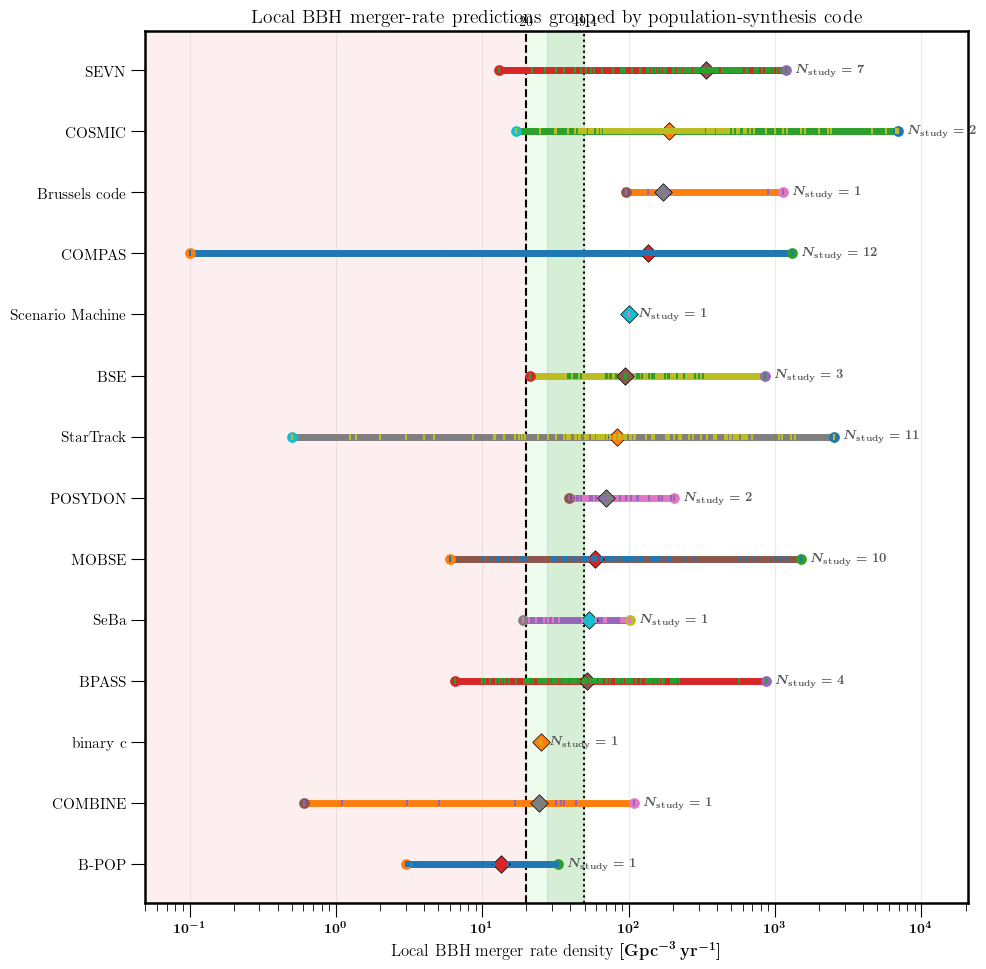

In [7]:
# ── Overview of BBH local merger-rate ranges by population-synthesis code ───

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = Path("../Data_Mandel_and_Broekgaarden_2026")

BOCO_R0 = 20.0
GWTC5_LOW = 27.5
GWTC5_HIGH = 49.4

# Load main rate table
main = pd.read_csv(DATA_DIR / "isolated-binary-evolution.csv", dtype=str).fillna("")

# Keep only BBH/BH-BH rows
code_df = main.copy()
code_df = code_df[
    code_df["compact_object_type"]
    .str.lower()
    .str.replace(" ", "", regex=False)
    .isin(["bbh", "bhbh", "bh-bh", "bh+bh"])
].copy()

# Convert rates and years to numeric
code_df["rate"] = pd.to_numeric(code_df["rate_Gpc3yr"], errors="coerce")
code_df["year"] = pd.to_numeric(code_df["year"], errors="coerce")

# Keep finite positive rates
code_df = code_df[np.isfinite(code_df["rate"]) & (code_df["rate"] > 0)].copy()

# Clean code labels
code_df["code"] = (
    code_df["code"]
    .replace({"": "Unknown", "nan": "Unknown", "None": "Unknown"})
    .fillna("Unknown")
    .astype(str)
    .str.strip()
)

# Optional: clean a few common aliases
code_df["code"] = code_df["code"].replace({
    "COMPAS ": "COMPAS",
    "SEVN ": "SEVN",
    "Startrack": "StarTrack",
    "StarTrack ": "StarTrack",
    "COSMIC ": "COSMIC",
    "MOBSE ": "MOBSE",
    "BPASS ": "BPASS",
})

# Remove exact duplicate model entries
dedup_cols = ["study_key", "submodel", "code", "rate"]
code_df = code_df.drop_duplicates(subset=dedup_cols)

print(f"BBH rate rows: {len(code_df)}")
print(f"Unique studies: {code_df['study_key'].nunique()}")
print(f"Unique codes: {code_df['code'].nunique()}")
print(sorted(code_df["code"].unique()))

display(code_df[[
    "compact_object_type", "study_key", "label", "year",
    "code", "submodel", "rate"
]].head(20))



# ── Summary statistics by code ───────────────────────────────────────────────

code_summary = (
    code_df
    .groupby("code")
    .agg(
        r_min=("rate", "min"),
        r_median=("rate", "median"),
        r_max=("rate", "max"),
        n_models=("rate", "size"),
        n_studies=("study_key", "nunique"),
        n_below_20=("rate", lambda x: (x < BOCO_R0).sum()),
        n_below_49p4=("rate", lambda x: (x < GWTC5_HIGH).sum()),
    )
    .reset_index()
)

code_summary["factor_range"] = code_summary["r_max"] / code_summary["r_min"]
code_summary["dex_range"] = np.log10(code_summary["factor_range"])

# Choose one sorting:
code_summary = code_summary.sort_values("r_median", ascending=True).reset_index(drop=True)
# code_summary = code_summary.sort_values("dex_range", ascending=True).reset_index(drop=True)

display(code_summary)


# ── Plot rate ranges by population-synthesis code ───────────────────────────

fig_h = max(4.5, 0.7 * len(code_summary))
fig, ax = plt.subplots(figsize=(10, fig_h))

y_positions = np.arange(len(code_summary))

ax.set_xscale("log")

xmin = max(1e-2, code_summary["r_min"].min() / 2)
xmax = code_summary["r_max"].max() * 3

# --------------------------------------------------------------------------
# Background observational regions
# --------------------------------------------------------------------------

ax.axvspan(xmin, BOCO_R0,
           color="lightcoral", alpha=0.12,
           label=r"$R<20$")

ax.axvspan(BOCO_R0, GWTC5_HIGH,
           color="lightgreen", alpha=0.15,
           label=r"$20<R<49.4$")

ax.axvspan(GWTC5_LOW, GWTC5_HIGH,
           color="forestgreen", alpha=0.12)

# Reference lines
ax.axvline(BOCO_R0, color="k", lw=1.5, ls="--")
ax.axvline(GWTC5_HIGH, color="k", lw=1.5, ls=":")

# --------------------------------------------------------------------------
# Draw one row per code
# --------------------------------------------------------------------------

for i, (_, row) in enumerate(code_summary.iterrows()):

    code = row["code"]

    # all individual models for this code
    sub = code_df[code_df["code"] == code]

    # faint points
    ax.scatter(
        sub["rate"],
        np.full(len(sub), i),
        alpha=1,
        s=18,
        zorder=12,
        marker='|'
    )

    # range line
    ax.plot(
        [row["r_min"], row["r_max"]],
        [i, i],
        lw=5,
        solid_capstyle="round",
        zorder=3,
    )

    # endpoints
    ax.scatter(row["r_min"], i, s=45, zorder=4)
    ax.scatter(row["r_max"], i, s=45, zorder=4)

    # median
    ax.scatter(
        row["r_median"],
        i,
        marker="D",
        s=80,
        edgecolor="k",
        linewidth=0.5,
        zorder=5,
    )

    # annotate number of studies
    ax.text(
        row["r_max"] * 1.15,
        i,
        rf"$N_{{\rm study}}={int(row['n_studies'])}$",
        va="center",
        fontsize=9,
        color="0.35",
    )

# --------------------------------------------------------------------------
# Formatting
# --------------------------------------------------------------------------

ax.set_yticks(y_positions)
ax.set_yticklabels(code_summary["code"], fontsize=11)

ax.set_xlabel(
    r"Local BBH merger rate density "
    r"$[\mathrm{Gpc}^{-3}\,\mathrm{yr}^{-1}]$",
    fontsize=12,
)

ax.set_xlim(xmin, xmax)

ax.grid(
    axis="x",
    which="major",
    alpha=0.25,
)

ax.set_title(
    "Local BBH merger-rate predictions grouped by population-synthesis code",
    fontsize=14,
)

# labels for observational constraints
ax.text(
    BOCO_R0,
    len(code_summary)-0.3,
    "20",
    ha="center",
    va="bottom",
    fontsize=10,
)

ax.text(
    GWTC5_HIGH,
    len(code_summary)-0.3,
    "49.4",
    ha="center",
    va="bottom",
    fontsize=10,
)

plt.tight_layout()

plt.savefig(
    "BBH_rate_ranges_by_population_synthesis_code.pdf",
    bbox_inches="tight",
)

plt.savefig(
    "BBH_rate_ranges_by_population_synthesis_code.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()


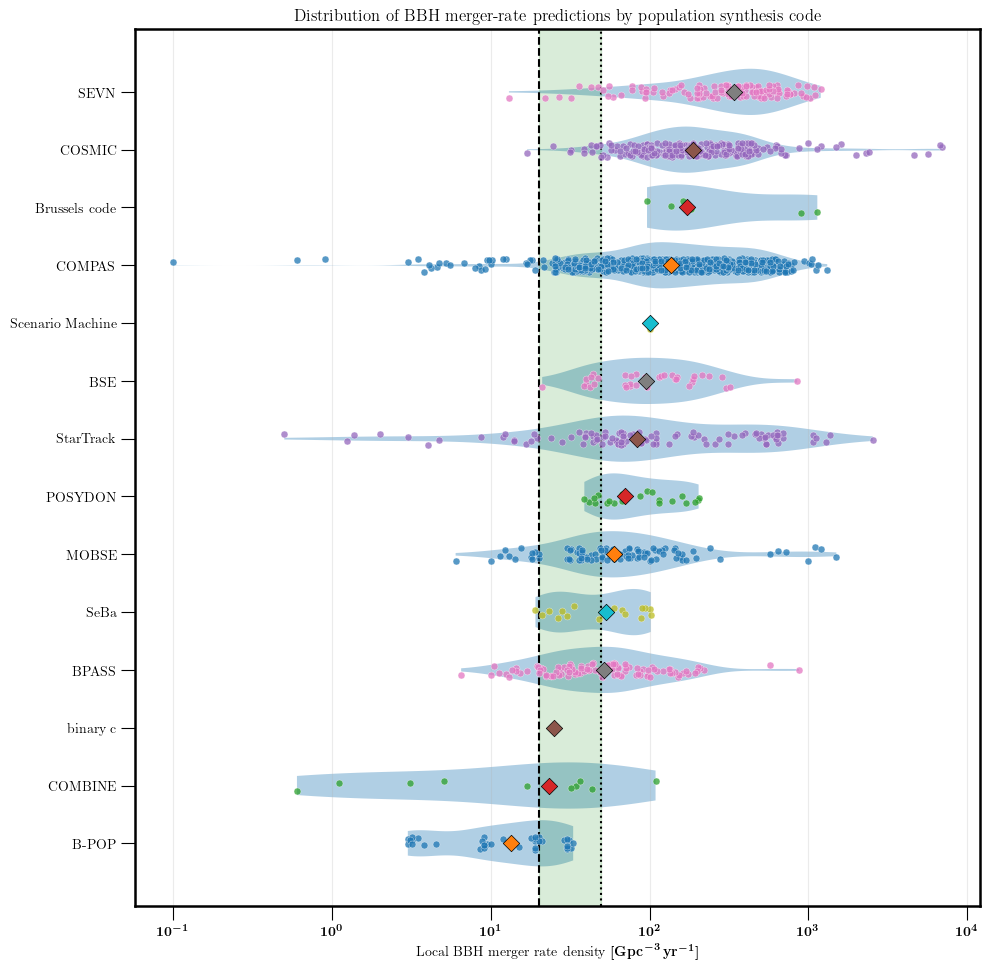

In [8]:
# ------------------------------------------------------------------
# Violin plot of BBH merger rates by population synthesis code
# ------------------------------------------------------------------

import numpy as np
import matplotlib.pyplot as plt

# Sort codes by median rate
code_order = (
    code_df.groupby("code")["rate"]
    .median()
    .sort_values()
    .index
)

# Build data arrays
violin_data = [
    np.log10(code_df.loc[code_df["code"] == code, "rate"])
    for code in code_order
]

fig_h = max(4.5, 0.7 * len(code_order))
fig, ax = plt.subplots(figsize=(10, fig_h))

# --------------------------------------------------------------
# Violin distributions
# --------------------------------------------------------------

parts = ax.violinplot(
    violin_data,
    vert=False,
    showmeans=False,
    showmedians=False,
    showextrema=False,
    widths=0.8,
)

for pc in parts["bodies"]:
    pc.set_alpha(0.35)

# --------------------------------------------------------------
# Overlay individual submodels
# --------------------------------------------------------------

rng = np.random.default_rng(42)

for i, code in enumerate(code_order, start=1):

    sub = code_df.loc[code_df["code"] == code]

    x = np.log10(sub["rate"])

    jitter = rng.uniform(-0.12, 0.12, len(sub))

    ax.scatter(
        x,
        i + jitter,
        s=25,
        alpha=0.75,
        zorder=3,
        edgecolor="white",
        linewidth=0.3,
    )

    # median
    median = np.median(x)

    ax.scatter(
        median,
        i,
        marker="D",
        s=70,
        edgecolor="black",
        linewidth=0.5,
        zorder=4,
    )

# --------------------------------------------------------------
# Observational constraints
# --------------------------------------------------------------

ax.axvspan(
    np.log10(BOCO_R0),
    np.log10(GWTC5_HIGH),
    alpha=0.15,
    color="green",
)

ax.axvline(
    np.log10(BOCO_R0),
    color="k",
    ls="--",
    lw=1.5,
)

ax.axvline(
    np.log10(GWTC5_HIGH),
    color="k",
    ls=":",
    lw=1.5,
)

# --------------------------------------------------------------
# Axes
# --------------------------------------------------------------

ax.set_yticks(np.arange(1, len(code_order)+1))
ax.set_yticklabels(code_order)

# Convert back to physical units on ticks
xticks = np.arange(
    np.floor(np.log10(code_df["rate"].min())),
    np.ceil(np.log10(code_df["rate"].max())) + 1
)

ax.set_xticks(xticks)
ax.set_xticklabels(
    [rf"$10^{{{int(x)}}}$" for x in xticks]
)

ax.set_xlabel(
    r"Local BBH merger rate density "
    r"$[\mathrm{Gpc}^{-3}\,\mathrm{yr}^{-1}]$"
)

ax.set_title(
    "Distribution of BBH merger-rate predictions by population synthesis code"
)

ax.grid(axis="x", alpha=0.25)

plt.tight_layout()
plt.show()

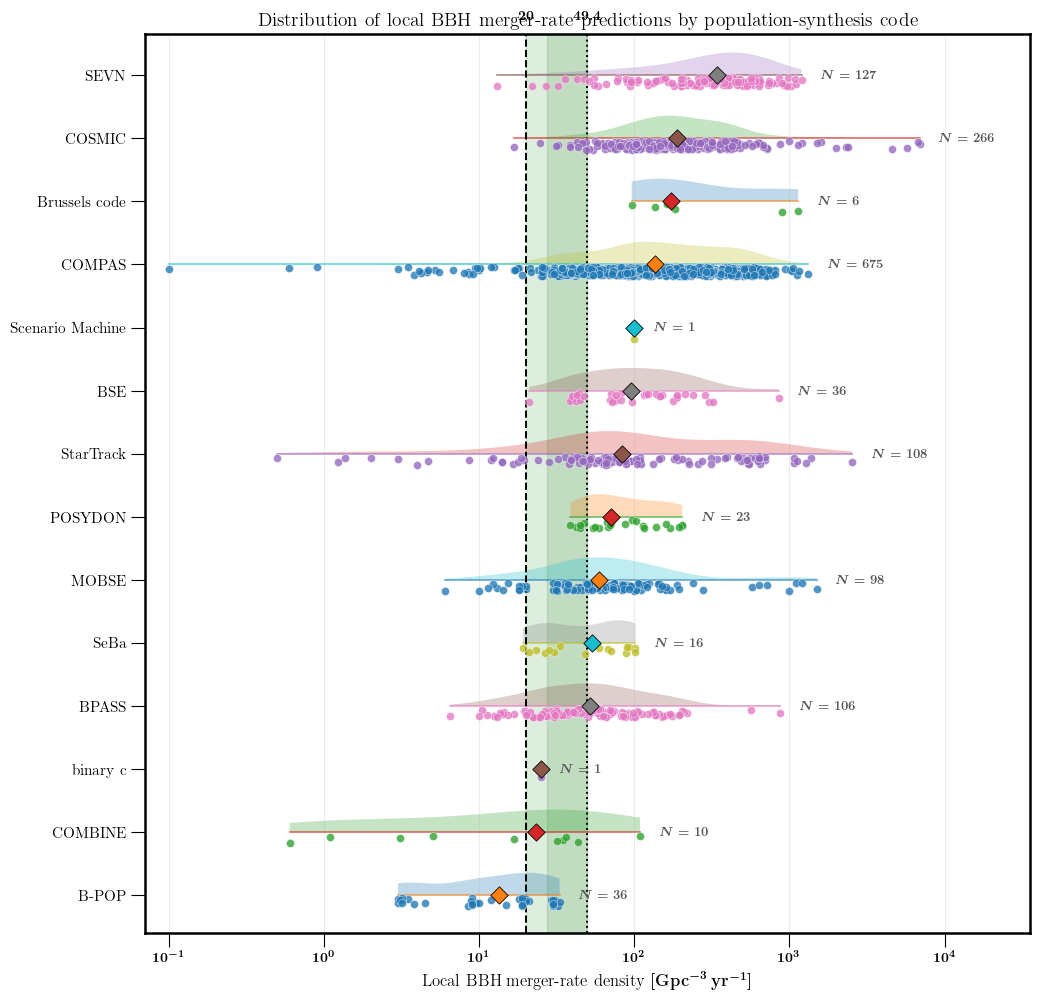

In [9]:
# ── Raincloud plot: BBH merger rates by population-synthesis code ───────────

import numpy as np
import matplotlib.pyplot as plt

code_order = (
    code_df.groupby("code")["rate"]
    .median()
    .sort_values()
    .index
)

fig_h = max(4.8, 0.72 * len(code_order))
fig, ax = plt.subplots(figsize=(10.5, fig_h))

rng = np.random.default_rng(42)

for i, code in enumerate(code_order):
    sub = code_df[code_df["code"] == code].copy()
    x = np.log10(sub["rate"].values)

    # Violin only if enough points
    if len(x) >= 3:
        parts = ax.violinplot(
            [x],
            positions=[i],
            vert=False,
            widths=0.72,
            showmeans=False,
            showmedians=False,
            showextrema=False,
        )

        for body in parts["bodies"]:
            body.set_alpha(0.28)
            body.set_zorder(1)

            # Make it a half violin: keep only upper half
            path = body.get_paths()[0]
            vertices = path.vertices
            vertices[:, 1] = np.maximum(vertices[:, 1], i)

    # Individual submodels, shifted downward
    jitter = rng.uniform(-0.18, -0.04, len(x))

    ax.scatter(
        x,
        i + jitter,
        s=34,
        alpha=0.78,
        edgecolor="white",
        linewidth=0.35,
        zorder=3,
    )

    # Median marker
    ax.scatter(
        np.median(x),
        i,
        marker="D",
        s=78,
        edgecolor="black",
        linewidth=0.6,
        zorder=4,
    )

    # Min-max whisker, subtle
    ax.plot(
        [np.min(x), np.max(x)],
        [i, i],
        lw=1.2,
        alpha=0.65,
        zorder=2,
    )

    # Count annotation
    ax.text(
        np.max(x) + 0.12,
        i,
        rf"$N={len(x)}$",
        va="center",
        fontsize=9,
        color="0.35",
    )

# Observational comparison region
ax.axvspan(
    np.log10(BOCO_R0),
    np.log10(GWTC5_HIGH),
    alpha=0.13,
    color="green",
    zorder=0,
)

ax.axvspan(
    np.log10(GWTC5_LOW),
    np.log10(GWTC5_HIGH),
    alpha=0.13,
    color="darkgreen",
    zorder=0,
)

ax.axvline(np.log10(BOCO_R0), color="k", ls="--", lw=1.4)
ax.axvline(np.log10(GWTC5_HIGH), color="k", ls=":", lw=1.4)

# Axes
ax.set_yticks(np.arange(len(code_order)))
ax.set_yticklabels(code_order, fontsize=11)

xmin = np.floor(np.log10(code_df["rate"].min()))
xmax = np.ceil(np.log10(code_df["rate"].max()))
xticks = np.arange(xmin, xmax + 1)

ax.set_xticks(xticks)
ax.set_xticklabels([rf"$10^{{{int(t)}}}$" for t in xticks])

ax.set_xlim(xmin - 0.15, xmax + 0.55)
ax.set_ylim(-0.6, len(code_order) - 0.35)

ax.set_xlabel(
    r"Local BBH merger-rate density "
    r"$[\mathrm{Gpc}^{-3}\,\mathrm{yr}^{-1}]$",
    fontsize=12,
)

ax.set_title(
    "Distribution of local BBH merger-rate predictions by population-synthesis code",
    fontsize=14,
)

ax.grid(axis="x", alpha=0.24)

# Label comparison lines
ax.text(
    np.log10(BOCO_R0),
    len(code_order) - 0.15,
    r"$20$",
    ha="center",
    va="bottom",
    fontsize=10,
)

ax.text(
    np.log10(GWTC5_HIGH),
    len(code_order) - 0.15,
    r"$49.4$",
    ha="center",
    va="bottom",
    fontsize=10,
)

plt.tight_layout()

plt.savefig(
    "BBH_rate_raincloud_by_population_synthesis_code.pdf",
    bbox_inches="tight",
)

plt.savefig(
    "BBH_rate_raincloud_by_population_synthesis_code.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [10]:
# ── Tables: submodel variations below observational comparison rates ─────────

import pandas as pd
import numpy as np

BOCO_R0 = 20.0
GWTC5_HIGH = 49.4

# Clean table from pts
rate_table = pts.copy()
rate_table = rate_table[np.isfinite(rate_table["rate"]) & (rate_table["rate"] > 0)]

# Optional: remove exact duplicates across panels if the same study/submodel appears several times
# Comment this out if you want to keep each parameter-family appearance.
rate_table = rate_table.drop_duplicates(
    subset=["study_key", "submodel", "rate"]
)

# Add useful flags
rate_table["below_49p4"] = rate_table["rate"] < GWTC5_HIGH
rate_table["below_20"] = rate_table["rate"] < BOCO_R0

# Sort in a useful order
rate_table = rate_table.sort_values(
    ["below_20", "below_49p4", "rate"],
    ascending=[False, False, True]
)

# Select columns for display
cols = [
    "panel",
    "label",
    "study_key",
    "submodel",
    "rate",
    "is_fiducial",
]

below_49p4 = (
    rate_table[rate_table["below_49p4"]]
    .sort_values(["rate", "panel", "label"])
    [cols]
    .reset_index(drop=True)
)

# Find where rates first exceed 20
split_idx = (below_49p4["rate"] >= 20).idxmax()

# Separator row
separator = pd.DataFrame({
    c: ["──────── Above 20 Gpc$^{-3}$ yr$^{-1}$ ────────"]
    if c == "panel" else [""]
    for c in below_49p4.columns
})

# Insert separator
below_49p4_display = pd.concat(
    [
        below_49p4.iloc[:split_idx],
        separator,
        below_49p4.iloc[split_idx:]
    ],
    ignore_index=True
)

display(below_49p4_display)

# pd.set_option("display.max_rows", 200)
# pd.set_option("display.max_colwidth", 120)

# print(f"Submodels with R_BBH < {GWTC5_HIGH} Gpc^-3 yr^-1: {len(below_49p4)}")
# display(below_49p4)

# print(f"Submodels with R_BBH < {BOCO_R0} Gpc^-3 yr^-1: {len(below_20)}")
# display(below_20)

,panel,label,study_key,submodel,rate,is_fiducial
0,Angular momentum \& winds,van Son (2022) SMT only,vanSon_2022_SMT_COMPAS,vanSon_f_disk_0.75,0.1,False
1,Natal kicks ($\sigma_{\rm kick}$),Boesky et al. (2024),Boesky_2024_COMPAS,Boesky_sigma_750_RMP_M,0.599,False
2,MT stability,van Son (2022) SMT only,vanSon_2022_SMT_COMPAS,vanSon_zeta_eff_3.5,0.9,False
3,CE efficiency ($\alpha_{\rm CE}$),Chattaraj (2025; solar metallicity),Chattaraj_2025_POSYDON,Chattaraj25-MODEL01,1.19,False
4,Remnant mass prescription,Chattaraj (2025; solar metallicity),Chattaraj_2025_POSYDON,Chattaraj25-MODEL07,1.35,False
...,...,...,...,...,...,...
162,Angular momentum \& winds,Rauf et al. (2024),Rauf_2024_COMPAS,Rauf24-MandelMuller2020-fWR0.2,47.0,False
163,MT efficiency ($\beta$),Dorozsmai \& Toonen (2022),Dorozsmai_2022_SeBa,DT22-beta0-3-gamma1-IT,47.8,False
164,Other,Srinivasan et al. (2023),Srinivasan_2023_COSMIC,S23-M11-KK04,48.9,False
165,CE criterion \& pessimistic/optimistic,Neijssel et al. (2019),Neijssel_2019_COMPAS,Neijssel_pess_fiducial,49.0,True


In [11]:
below_49p4.to_csv("submodels_below_49p4_Gpc3yr.csv", index=False)
# below_20.to_csv("submodels_below_20_Gpc3yr.csv", index=False)
# counts_by_panel.to_csv("submodel_counts_by_parameter_family.csv", index=False)

In [12]:
# ── Compact counts by parameter family ───────────────────────────────────────

counts_by_panel = (
    rate_table
    .groupby("panel")
    .agg(
        n_total=("rate", "size"),
        n_below_20=("below_20", "sum"),
        n_below_49p4=("below_49p4", "sum"),
        r_min=("rate", "min"),
        r_median=("rate", "median"),
        r_max=("rate", "max"),
    )
    .reset_index()
)

counts_by_panel["frac_below_20"] = counts_by_panel["n_below_20"] / counts_by_panel["n_total"]
counts_by_panel["frac_below_49p4"] = counts_by_panel["n_below_49p4"] / counts_by_panel["n_total"]

counts_by_panel = counts_by_panel.sort_values("frac_below_49p4", ascending=False)

display(counts_by_panel)

,panel,n_total,n_below_20,n_below_49p4,r_min,r_median,r_max,frac_below_20,frac_below_49p4
5,MT stability,14,4,10,0.900,27.2000,695.000,0.285714,0.714286
0,Angular momentum \& winds,13,4,8,0.100,43.8000,579.000,0.307692,0.615385
9,Remnant mass prescription,42,13,18,1.350,57.4500,438.000,0.309524,0.428571
11,Stellar evolution tracks,14,3,5,3.000,65.0915,162.181,0.214286,0.357143
4,MT efficiency ($\beta$),33,3,9,10.100,96.2090,417.000,0.090909,0.272727
3,Initial conditions,4,0,1,22.000,134.9000,203.000,0.000000,0.250000
7,Natal kicks ($\sigma_{\rm kick}$),24,4,5,0.599,177.9250,1072.000,0.166667,0.208333
2,CE efficiency ($\alpha_{\rm CE}$),437,25,86,1.190,168.2460,1195.800,0.057208,0.196796
10,Star formation history,79,1,12,16.900,109.0000,1157.220,0.012658,0.151899
1,CE criterion \& pessimistic/optimistic,26,2,3,3.160,182.7800,714.150,0.076923,0.115385


In [13]:
# below_49p4.to_csv("submodels_below_49p4_Gpc3yr.csv", index=False)
# below_20.to_csv("submodels_below_20_Gpc3yr.csv", index=False)
# counts_by_panel.to_csv("submodel_counts_by_parameter_family.csv", index=False)

## parameter relationship

In [14]:


# Keep rows with both rates known
df = rels.copy()

df["from_rate_Gpc3yr"] = pd.to_numeric(df["from_rate_Gpc3yr"], errors="coerce")
df["to_rate_Gpc3yr"] = pd.to_numeric(df["to_rate_Gpc3yr"], errors="coerce")

df = df.dropna(subset=["from_rate_Gpc3yr", "to_rate_Gpc3yr"])

LIMIT = 49.4

successful = df[
    (df["from_rate_Gpc3yr"] > LIMIT) &
    (df["to_rate_Gpc3yr"] < LIMIT)
].copy()

successful["rate_reduction_factor"] = (
    successful["from_rate_Gpc3yr"] /
    successful["to_rate_Gpc3yr"]
)

successful = successful.sort_values(
    "rate_reduction_factor",
    ascending=False
)

display(
    successful[
        [
            "label",
            "parameter_family",
            "parameter",
            "travel_label",
            "from_value", 
            "to_value",
            "from_rate_Gpc3yr",
            "to_rate_Gpc3yr",
            "rate_reduction_factor",
        ]
    ]
)

,label,parameter_family,parameter,travel_label,from_value,to_value,from_rate_Gpc3yr,to_rate_Gpc3yr,rate_reduction_factor
197,Boesky et al. (2024),remnant mass prescription,supernova_engine,MM SN,Rapid,Müller+Mandel,82.639,0.599,137.961603
187,Boesky et al. (2024),natal kick,sigma_kick,$\sigma_{\rm kick} \uparrow$,30,265,433.439,19.019,22.789789
163,Romagnolo et al. (2025),stellar tracks,convection_criterion,tracks,SSE,Klencki ML1.5,63.600,3.000,21.200000
146,Belczynski et al. (2020),angular momentum,BH_spin_coupling,spin coupling on,no coupling (default),magnetic spin-down,579.000,43.800,13.219178
252,van Son (2022) SMT only,angular momentum,f_disk,$f_{\rm disk} \uparrow$,0.25,0.5,118.400,12.000,9.866667
194,Boesky et al. (2024),remnant mass prescription,supernova_engine,MM SN,Rapid,Müller+Mandel,139.387,19.019,7.328829
280,Srinivasan et al. (2023),BH natal-kick scaling (v_BH),bhflag,bhflag=3 (kick not scaled by fallback),default,bhflag=3 (kick not scaled by fallback),261.000,46.900,5.565032
284,Srinivasan et al. (2023),BH natal-kick scaling (v_BH),bhflag,bhflag=3 (kick not scaled by fallback),default,bhflag=3 (kick not scaled by fallback),173.000,31.300,5.527157
279,Srinivasan et al. (2023),BH natal-kick scaling (v_BH),bhflag,bhflag=3 (kick not scaled by fallback),default,bhflag=3 (kick not scaled by fallback),91.200,16.900,5.396450
984,van Son et al. (2023),star formation history,SFRD_model,$\mu_0=0.035$,$\mu_0=0.007$ (low mean metallicity),$\mu_0=0.035$ (high mean metallicity),209.500,38.900,5.385604


In [15]:
# how often a rate below limit 

LIMIT = 49.4

below_limit = df[
    (df["to_rate_Gpc3yr"] < LIMIT)
].copy()

summary = (
    below_limit
    .groupby(["parameter_family"])
    .agg(
        N=("parameter_family","size"),
        median_rate=("to_rate_Gpc3yr","median"),
        min_rate=("to_rate_Gpc3yr","min"),
        max_rate=("to_rate_Gpc3yr","max")
    )
    .sort_values("N", ascending=False)
)

display(summary)

,N,median_rate,min_rate,max_rate
parameter_family,,,,
common envelope efficiency (alpha_CE),54,22.698,9.594,43.173
remnant mass prescription,18,7.400,0.599,46.000
stellar tracks,10,18.700,3.000,46.600
star formation history,9,38.900,24.800,48.900
natal kick,9,25.000,0.599,39.000
mass transfer efficiency,8,27.200,17.000,39.600
BH natal-kick scaling (v_BH),5,31.300,16.900,46.900
CE efficiency & binding energy (alpha & lambda),5,43.200,38.400,49.200
angular momentum,5,12.000,0.000,43.800


In [16]:
# shows lowest rate due to travel 

LIMIT = 49.4

allowed = df[df["to_rate_Gpc3yr"] < LIMIT]

best = (
    allowed
    .sort_values("to_rate_Gpc3yr")
    .groupby("parameter_family")
    .first()
    .reset_index()
)

display(
    best[
        [
            "parameter_family",
            "travel_label",
            "to_rate_Gpc3yr"
        ]
    ]
)

,parameter_family,travel_label,to_rate_Gpc3yr
0,BH natal-kick scaling (v_BH),bhflag=3 (kick not scaled by fallback),16.900
1,CE core-envelope boundary (H-fraction),1% H-fraction,12.330
2,CE efficiency & binding energy (alpha & lambda),"alpha=0.3, lambda=1",38.400
3,CE efficiency (alpha),$\alpha_{\rm CE}=3$,5.220
4,CE onset critical mass ratio (q_crit),qcflag=4 (Belczynski et al. 2008),42.900
5,CE treatment (post-CE mass loss),Windloss,3.160
6,angular momentum,$f_{\rm disk} \uparrow$,0.000
7,common envelope efficiency,$\alpha_{\rm CE} \downarrow$,21.000
8,common envelope efficiency (alpha_CE),$\alpha_{\rm CE} \uparrow$,9.594
9,convective envelope criteria,IT criterion,19.100


# make mega multi parameter plot 

In [17]:
# ── Drawing helpers ───────────────────────────────────────────────────────────

# Palette for color-coding disjoint "chains" (connected components of edges)
# within a single study's row. Chain 0 reuses IBE_COLOR so a study with only
# one chain looks unchanged.
CHAIN_COLORS = [
    IBE_COLOR,   # 0: warm orange
    "#2980b9",   # 1: blue
    "#27ae60",   # 2: green
    "#8e44ad",   # 3: purple
    "#c0392b",   # 4: red
    "#16a085",   # 5: teal
    "#d68910",   # 6: amber
    "#34495e",   # 7: slate
]

# Small per-chain vertical jitter so that chains overlapping in rate still
# show up as separate horizontal lines. Chain 0 gets zero jitter so a study
# with a single chain is drawn exactly on its row's center line. Fixed seed
# keeps the figure reproducible across re-runs.
CHAIN_Y_JITTER = np.random.default_rng(42).uniform(-0.09, 0.09, size=len(CHAIN_COLORS))
CHAIN_Y_JITTER[0] = 0.0


def _edge_chains(study_edges):
    """Union-find over from_submodel/to_submodel: returns {submodel: chain_index}
    so each connected component ("chain") of edges gets its own index."""
    parent = {}

    def find(x):
        while parent[x] != x:
            x = parent[x]
        return x

    def union(a, b):
        ra, rb = find(a), find(b)
        if ra != rb:
            parent[ra] = rb

    for _, erow in study_edges.iterrows():
        a, b = erow["from_submodel"], erow["to_submodel"]
        parent.setdefault(a, a)
        parent.setdefault(b, b)
        union(a, b)

    chain_idx = {}
    for node in parent:
        root = find(node)
        if root not in chain_idx:
            chain_idx[root] = len(chain_idx)
    return {node: chain_idx[find(node)] for node in parent}


def draw_study_in_panel(ax, study_pts, study_edges, y, color=IBE_COLOR,
                        fiducial_color=FIDUCIAL_COLOR, fiducial_edge=FIDUCIAL_EDGE,
                        color_chains=False):
    sub = study_pts.drop_duplicates("submodel").dropna(subset=["rate"])
    if sub.empty:
        return

    # Optionally give each disjoint chain of edges its own color (and a tiny
    # vertical offset), so e.g. Boesky's alpha_CE sweeps at 3 fixed beta_MT
    # values, or van Son's f_core vs f_mix chains in "Remnant mass
    # prescription", are visually distinguishable rather than blending
    # into one bar.
    chain_of = _edge_chains(study_edges) if color_chains else {}

    def chain_y(submodel):
        if color_chains and submodel in chain_of:
            return y + CHAIN_Y_JITTER[chain_of[submodel] % len(CHAIN_COLORS)]
        return y

    # One line segment per relationship (edge) directly connecting the two
    # submodels it relates — not a single min-to-max bar across all points.
    for _, erow in study_edges.iterrows():
        c = chain_of.get(erow["from_submodel"], 0) % len(CHAIN_COLORS) if color_chains else 0
        edge_color = CHAIN_COLORS[c] if color_chains else color
        yy = y + CHAIN_Y_JITTER[c] if color_chains else y
        ax.plot([erow["from_rate"], erow["to_rate"]], [yy, yy],
                color=edge_color, lw=3.0, zorder=3, alpha=0.55, solid_capstyle="butt")
    for _, row in sub.iterrows():
        r  = row["rate"]
        yy = chain_y(row["submodel"])
        if row["is_fiducial"]:
            ax.scatter(r, yy, s=280, marker="*",
                       c=fiducial_color, edgecolors=fiducial_edge,
                       linewidths=1.2, zorder=100)
        else:
            pt_color = (CHAIN_COLORS[chain_of[row["submodel"]] % len(CHAIN_COLORS)]
                        if (color_chains and row["submodel"] in chain_of) else color)
            ax.scatter(r, yy, s=50, marker="|",
                       c=[pt_color], edgecolors="k",
                       linewidths=1.7, zorder=50)


def style_panel(ax, xmin, xmax):
    ax.set_xscale("log")
    ax.set_xlim(xmin, xmax)
    ax.set_yticks([])
    ax.tick_params(which="major", length=8, width=1.2, labelsize=FONTSIZE - 2)
    ax.tick_params(which="minor", length=4, width=1.0)
    for spine in ax.spines.values():
        spine.set_linewidth(1.2)
    for xv in [1e-3, 1e-2, 1e-1, 1, 10, 1e2, 1e3, 1e4]:
        if xmin <= xv <= xmax:
            ax.axvline(xv, lw=0.8, color="0.75", ls=":", zorder=0)

In [18]:
# ── Diagnostic: which studies appear in which panels ─────────────────────────
summary = (pts.drop_duplicates(["panel","study_key"])
              .sort_values(["panel","year"])[["panel","study_key","label","year"]]
              .reset_index(drop=True))
display(summary)

,panel,study_key,label,year
0,Angular momentum \& winds,Belczynski_2020_StarTrack,Belczynski et al. (2020),2020
1,Angular momentum \& winds,Dorozsmai_2022_SeBa,Dorozsmai \& Toonen (2022),2022
2,Angular momentum \& winds,vanSon_2022_SMT_COMPAS,van Son (2022) SMT only,2022
3,Angular momentum \& winds,Rauf_2024_COMPAS,Rauf et al. (2024),2024
4,Angular momentum \& winds,Li_2025_MOBSE,Li et al. (2025),2025
5,CE criterion \& pessimistic/optimistic,Mapelli_2017_MOBSE,Mapelli et al. (2017),2017
6,CE criterion \& pessimistic/optimistic,Neijssel_2019_COMPAS,Neijssel et al. (2019),2019
7,CE criterion \& pessimistic/optimistic,Olejak_2021_Startrack,Olejak et al. (2021),2021
8,CE criterion \& pessimistic/optimistic,Olejak_2022_Startrack,Olejak et al. (2022),2022
9,CE criterion \& pessimistic/optimistic,Chattaraj_2025_POSYDON,Chattaraj (2025; solar metallicity),2025


## Maybe appendix figure 

Saved: parameter_impact_BHBH.pdf / .png


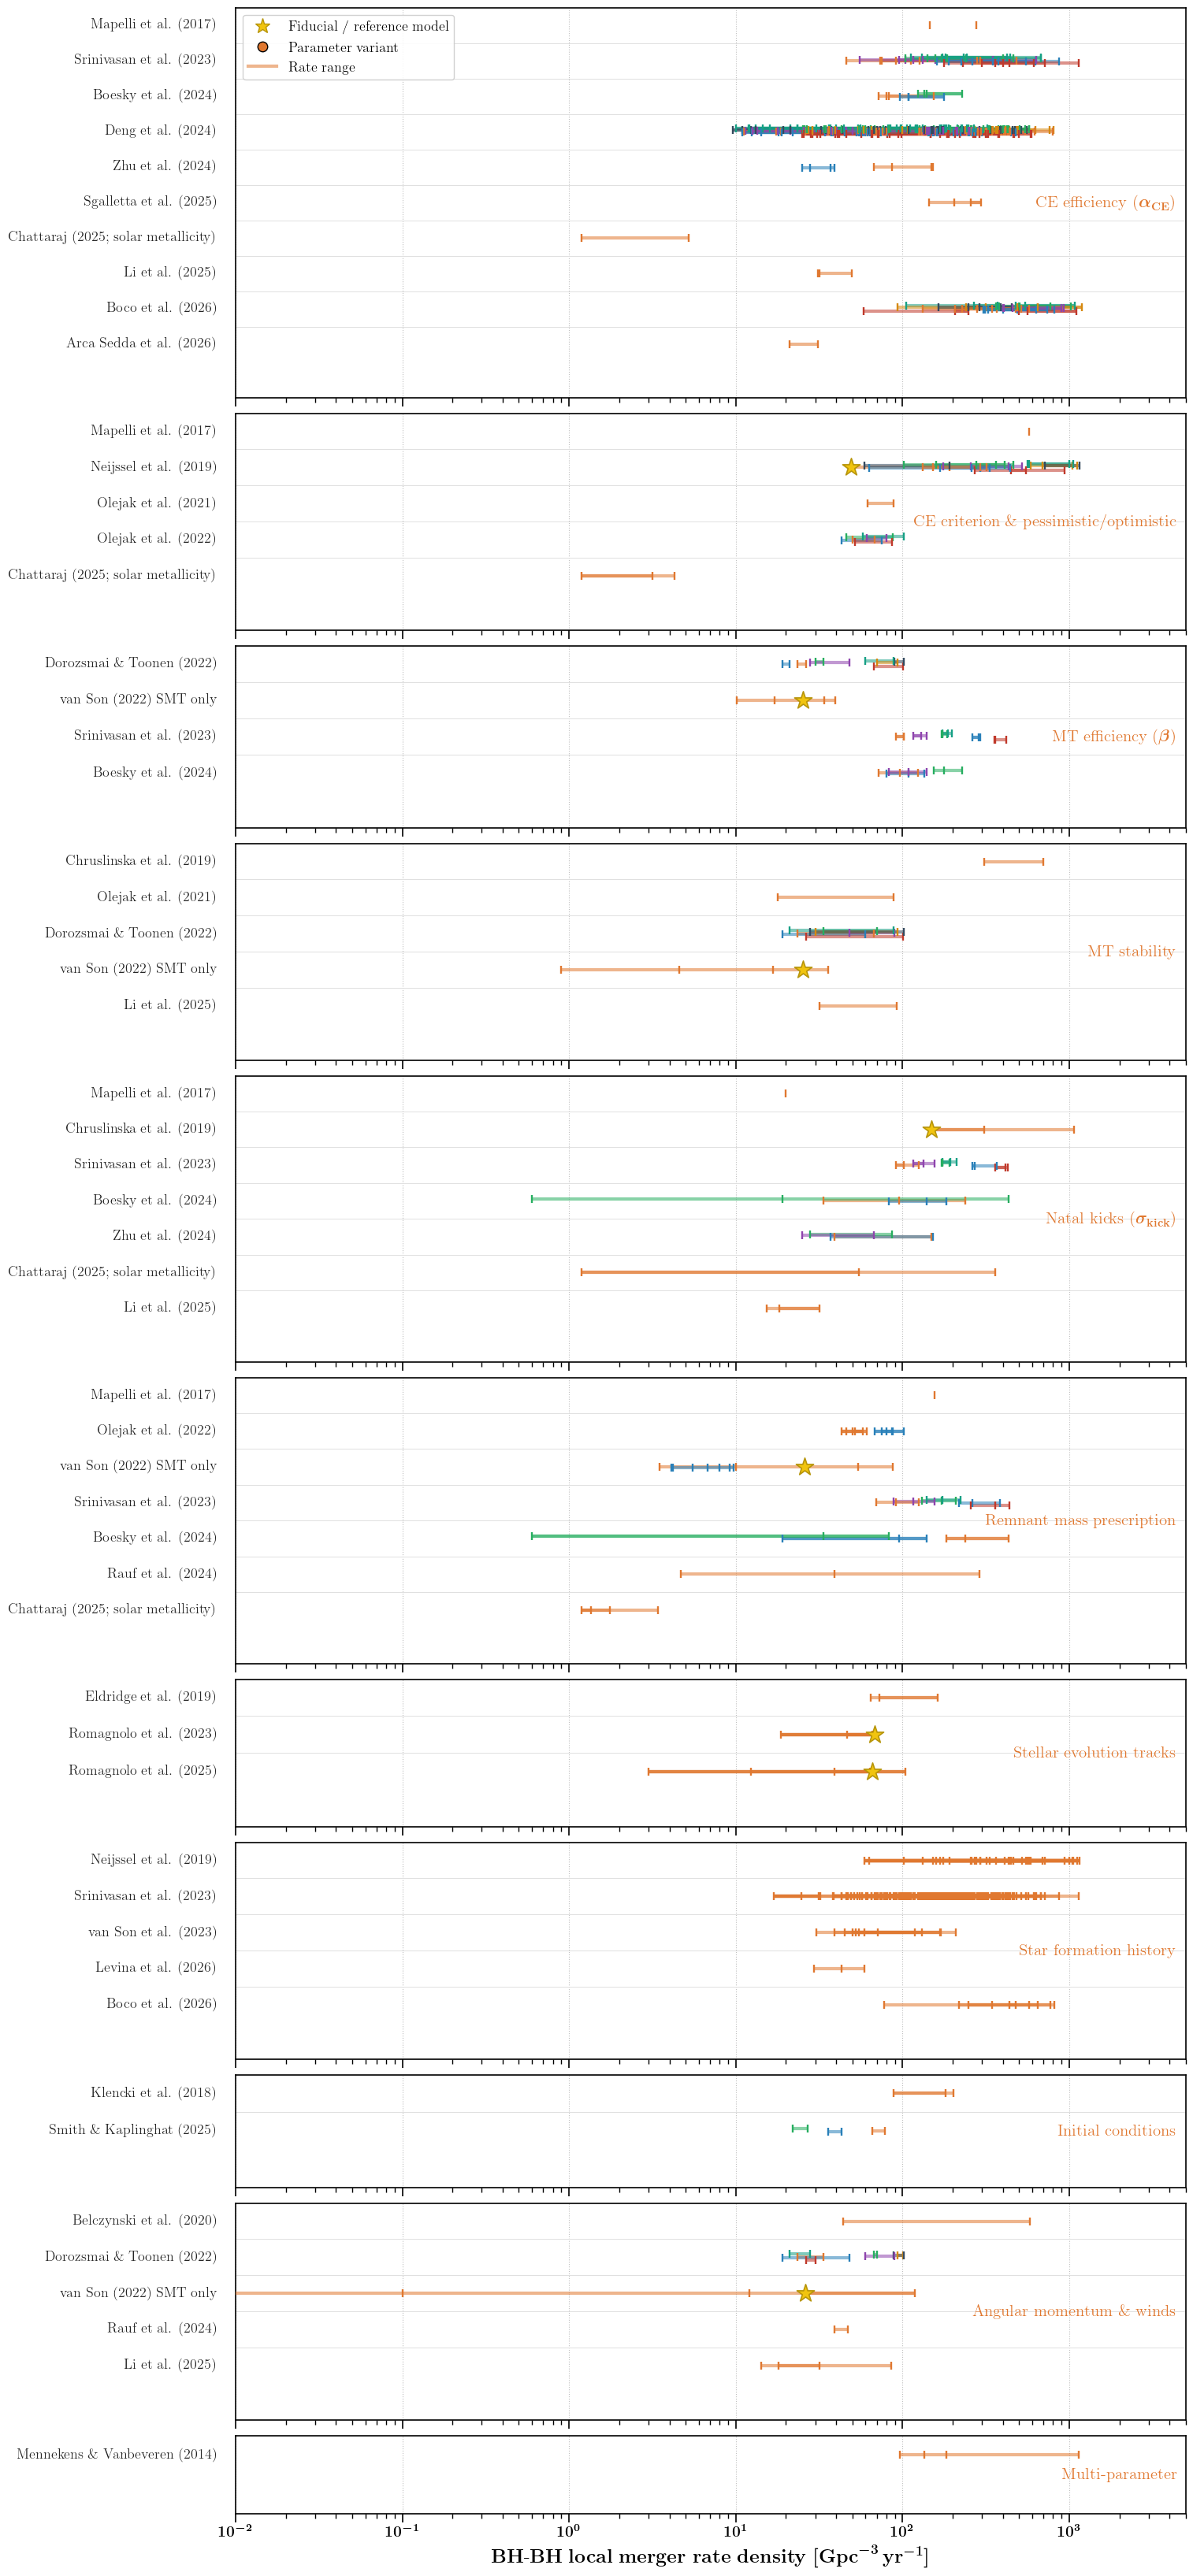

In [19]:
# ── Main figure ───────────────────────────────────────────────────────────────
from matplotlib.transforms import blended_transform_factory

XMIN, XMAX     = 1e-2, 5e3
FIG_WIDTH      = 18
ROW_H          = 0.44
PANEL_HDR_H    = 0.55
GAP_H          = 0.20
TOP_MARGIN     = 0.70
BOT_MARGIN     = 0.80
LABEL_FONTSIZE = FONTSIZE - 3

panel_heights = [len(panels[g]["studies"]) * ROW_H + PANEL_HDR_H for g in panels]
total_h = sum(panel_heights) + (len(panels) - 1) * GAP_H + TOP_MARGIN + BOT_MARGIN

fig = plt.figure(figsize=(FIG_WIDTH, total_h))

gs_heights = []
for i, h in enumerate(panel_heights):
    gs_heights.append(h)
    if i < len(panels) - 1:
        gs_heights.append(GAP_H)

gs = gridspec.GridSpec(
    nrows=len(gs_heights), ncols=1,
    height_ratios=gs_heights,
    left=0.30, right=0.97,
    top=1 - TOP_MARGIN / total_h,
    bottom=BOT_MARGIN / total_h,
    hspace=0,
)

axes = []
for panel_idx, (panel_name, panel) in enumerate(panels.items()):
    ax = fig.add_subplot(gs[panel_idx * 2, 0])
    style_panel(ax, XMIN, XMAX)
    axes.append(ax)

    studies   = panel["studies"]
    n_studies = len(studies)
    ax.set_ylim(-n_studies - 0.5, 0.5)

    trans_label = blended_transform_factory(ax.transAxes, ax.transData)

    for study_idx, sk in enumerate(studies):
        y           = -study_idx
        study_pts   = panel["pts"][panel["pts"]["study_key"] == sk]
        study_edges = panel["edges"][panel["edges"]["study_key"] == sk]

        draw_study_in_panel(ax, study_pts, study_edges, y,
                            color_chains=(panel_name != r"Star formation history"))

        # Labels in the relationships CSV are already LaTeX-formatted (e.g. \&)
        label_text = study_pts["label"].iloc[0]
        ax.text(-0.02, y, label_text,
                ha="right", va="center",
                fontsize=LABEL_FONTSIZE, color="0.15",
                transform=trans_label)

        if study_idx < n_studies - 1:
            ax.axhline(-study_idx - 0.5, color="0.88", lw=0.7, zorder=0)

    ax.text(0.99, 0.50, panel_name,
            ha="right", va="center",
            fontsize=FONTSIZE - 1, color=IBE_COLOR, fontweight="bold",
            transform=ax.transAxes)

    if panel_idx < len(panels) - 1:
        ax.tick_params(labelbottom=False)

axes[-1].set_xlabel(
    r"$\mathbf{BH\text{-}BH\ local\ merger\ rate\ density}\ [\mathrm{Gpc}^{-3}\,\mathrm{yr}^{-1}]$",
    fontsize=FONTSIZE + 2, labelpad=6,
)

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0],[0], marker="*", color="w", markerfacecolor=FIDUCIAL_COLOR,
           markeredgecolor=FIDUCIAL_EDGE, markersize=14, label="Fiducial / reference model"),
    Line2D([0],[0], marker="o", color="w", markerfacecolor=IBE_COLOR,
           markeredgecolor="k", markersize=9, label="Parameter variant"),
    Line2D([0],[0], color=IBE_COLOR, lw=3, alpha=0.55, label="Rate range"),
]
axes[0].legend(handles=legend_elements, loc="upper left",
               fontsize=FONTSIZE - 3, framealpha=0.9, edgecolor="0.8")

plt.savefig("parameter_impact_BHBH.pdf", bbox_inches="tight", dpi=200)
plt.savefig("parameter_impact_BHBH.png", bbox_inches="tight", dpi=200)
print("Saved: parameter_impact_BHBH.pdf / .png")
plt.show()

In [20]:
# ── Optional: per-panel close-up figures ─────────────────────────────────────

def make_single_panel(panel_name, save=False):
    if panel_name not in panels:
        print(f"Panel not found: {panel_name}")
        return
    panel    = panels[panel_name]
    studies  = panel["studies"]
    n_studies = len(studies)

    fig_h = n_studies * ROW_H + 1.5
    fig, ax = plt.subplots(figsize=(FIG_WIDTH * 0.7, fig_h))
    style_panel(ax, XMIN, XMAX)
    ax.set_ylim(-n_studies - 0.5, 0.5)

    from matplotlib.transforms import blended_transform_factory
    trans_label = blended_transform_factory(ax.transAxes, ax.transData)

    for study_idx, sk in enumerate(studies):
        y           = -study_idx
        study_pts   = panel["pts"][panel["pts"]["study_key"] == sk]
        study_edges = panel["edges"][panel["edges"]["study_key"] == sk]
        draw_study_in_panel(ax, study_pts, study_edges, y,
                            color_chains=(panel_name != r"Star formation history"))
        label_text = study_pts["label"].iloc[0]
        ax.text(-0.02, y, label_text, ha="right", va="center",
                fontsize=LABEL_FONTSIZE, color="0.15", transform=trans_label)
        ax.axhline(-study_idx - 0.5, color="0.88", lw=0.7, zorder=0)

    ax.set_title(panel_name, fontsize=FONTSIZE + 2, color=IBE_COLOR, pad=8)
    ax.set_xlabel(
        r"$\mathbf{BH\text{-}BH\ merger\ rate}\ [\mathrm{Gpc}^{-3}\,\mathrm{yr}^{-1}]$",
        fontsize=FONTSIZE,
    )
    plt.tight_layout()
    if save:
        import re
        slug = re.sub(r"[^\w]", "_", panel_name).strip("_").lower()
        plt.savefig(f"parameter_impact_BHBH_{slug}.pdf", bbox_inches="tight", dpi=200)
        plt.savefig(f"parameter_impact_BHBH_{slug}.png", bbox_inches="tight", dpi=200)
    plt.show()


# ── Uncomment any of these to get standalone panel figures: ─────────────────
# make_single_panel(r"CE efficiency ($\alpha_{\rm CE}$)", save=True)
# make_single_panel(r"MT efficiency ($\beta$)", save=True)
# make_single_panel(r"Natal kicks ($\sigma_{\rm kick}$)", save=True)

In [21]:
# ── Quick lookup: submodels for one study across all panels ──────────────────
STUDY_KEY = "Broekgaarden_COMPAS"   # change to any study_key

print(f"Submodels for {STUDY_KEY} (by panel):")
show = (pts[pts["study_key"] == STUDY_KEY]
          [["panel","submodel","rate","is_fiducial"]]
          .sort_values(["panel","rate"]))
pd.set_option("display.max_colwidth", 80)
display(show)

Submodels for Broekgaarden_COMPAS (by panel):


,panel,submodel,rate,is_fiducial
